##Часть 1

###Задание 1

Я выбрала белки, связанные с иммунной системой: P04439,	P01730,	P43628,	O00206,	P01375,	P01024,	P55899,	P11226,	P16410,	P05164;

алгоритм действий (я пошла от обратного):
1. поискала белки иммунной системы, которые теоретически должны быть и у человека, и у шимпанзе
2. для каждого из них нашла страницу в ensembl и там нашла ортолог, который есть у человека
3. нашла этот ортолог в uniprot и вставила в таблицу

In [82]:
import pandas as pd

In [83]:
orthologues_data = {
    'uniprot_id': ['P04439', 'P01730', 'P43628', 'O00206', 'P01375',
                   'P01024', 'P55899', 'P11226', 'P16410', 'P05164'],
    'identities': [None] * 10,
    'similarities': [None] * 10
}

In [84]:
df_orthologues = pd.DataFrame(orthologues_data)
df_orthologues #эту таблицу я чуть ниже заполнила

,uniprot_id,identities,similarities
0,P04439,None,None
1,P01730,None,None
2,P43628,None,None
3,O00206,None,None
4,P01375,None,None
5,P01024,None,None
6,P55899,None,None
7,P11226,None,None
8,P16410,None,None
9,P05164,None,None


Выравнивание я делала через BLAST – оттуда же брала значения identity & similarity для каждого белка

#####Здесь просто однотипные подсчеты

In [85]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P05164', 'identities'] = 140 / 145
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P05164', 'similarities'] = 142 / 145

In [86]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P16410', 'identities'] = 223 / 223
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P16410', 'similarities'] = 223 / 223

In [87]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P11226', 'identities'] = 241 / 243
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P11226', 'similarities'] = 243 / 243

In [88]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P55899', 'identities'] = 340 / 340
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P55899', 'similarities'] = 340 / 340

In [89]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P01024', 'identities'] = 460 / 465
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P01024', 'similarities'] = 463 / 465

In [90]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P01375', 'identities'] = 220 / 234
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P01375', 'similarities'] = 223 / 234

In [91]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'O00206', 'identities'] = 836 / 839
df_orthologues.loc[df_orthologues['uniprot_id'] == 'O00206', 'similarities'] = 838 / 839

In [92]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P43628', 'identities'] = 276 / 329
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P43628', 'similarities'] = 288 / 329

In [93]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P01730', 'identities'] = 453 / 458
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P01730', 'similarities'] = 454 / 458

In [94]:
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P04439', 'identities'] = 351 / 365
df_orthologues.loc[df_orthologues['uniprot_id'] == 'P04439', 'similarities'] = 356 / 365

#####Так выглядит общая таблица

In [95]:
df_orthologues

,uniprot_id,identities,similarities
0,P04439,0.961644,0.975342
1,P01730,0.989083,0.991266
2,P43628,0.838906,0.87538
3,O00206,0.996424,0.998808
4,P01375,0.940171,0.952991
5,P01024,0.989247,0.995699
6,P55899,1.0,1.0
7,P11226,0.99177,1.0
8,P16410,1.0,1.0
9,P05164,0.965517,0.97931


###Задание 2

Устанавливаем bedtools (с Божьей помощью)

In [96]:
!apt-get install bedtools samtools -q

Reading package lists...
Building dependency tree...
Reading state information...
samtools is already the newest version (1.13-4).
bedtools is already the newest version (2.30.0+dfsg-2ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [122]:
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
!gunzip hg38.fa.gz

#можно было скачать через ncbi, но так я уже просто делала для других задач и так было проще

--2026-05-09 12:41:24--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 983659424 (938M) [application/x-gzip]
Saving to: ‘hg38.fa.gz’

hg38.fa.gz          100%[===================>] 938.09M  45.2MB/s    in 22s     

2026-05-09 12:41:46 (43.5 MB/s) - ‘hg38.fa.gz’ saved [983659424/983659424]



In [123]:
!samtools faidx hg38.fa
#я честно скажу что очень не уверена в осмысленности кода с bedtools
#потому что меня не было в прошлом полугодии (я с другого майнора) и я мало поняла
#попыталась разобраться с гуглом и семинаром, это пришлось гуглить, но оно вроде работает

In [124]:
!bedtools random -g hg38.fa.fai -l 100 -n 100 > random_regions.bed

In [125]:
!cat random_regions.bed #так это выглядит

chr11	22188087	22188187	1	100	-
chr17	3294346	3294446	2	100	-
chr12	130214916	130215016	3	100	-
chr16	76532960	76533060	4	100	+
chr12	119596368	119596468	5	100	+
chr1	26586598	26586698	6	100	+
chr3	3804309	3804409	7	100	-
chr11	80666793	80666893	8	100	+
chr5	128952167	128952267	9	100	-
chr11	43922891	43922991	10	100	-
chr2	42194211	42194311	11	100	-
chr4	83130914	83131014	12	100	+
chr7	93235973	93236073	13	100	+
chrX	144689865	144689965	14	100	+
chr12	20950270	20950370	15	100	-
chr1	117510339	117510439	16	100	-
chrY	8399092	8399192	17	100	+
chrX	130278480	130278580	18	100	-
chrX	109376297	109376397	19	100	+
chr6	36956645	36956745	20	100	+
chr20	45928594	45928694	21	100	+
chr1	79188309	79188409	22	100	-
chrX	80194677	80194777	23	100	-
chr7	78195064	78195164	24	100	-
chr5	89851207	89851307	25	100	+
chr5	97710059	97710159	26	100	+
chr3	182357815	182357915	27	100	+
chr9	19114385	19114485	28	100	+
chr4	52863765	52863865	29	100	-
chr8	56671720	56671820	30	100	+
chr21	17915116	17915216	31	100

In [126]:
!bedtools getfasta -fi hg38.fa -bed random_regions.bed -fo genome.fasta #ура сохранили

*в отчете я пропускаю момент вставки таблицы в blast, переходим к этапу работы с полученной csv-таблицей*

In [127]:
df_chimp = pd.read_csv('/content/ZWGWKJRW016-Alignment-HitTable.csv',
                       usecols=[0, 2, 10],
                       names=['region', 'identity', 'e-value'])
df_chimp.head(10)

,region,identity,e-value
0,chr1:102713990-102714090,83.871,3.790000e-09
1,chr1:102713990-102714090,74.038,1.610000e-07
2,chr1:102713990-102714090,74.038,1.610000e-07
3,chr1:102713990-102714090,74.038,1.610000e-07
4,chr1:102713990-102714090,74.038,1.610000e-07
5,chr1:102713990-102714090,74.038,1.610000e-07
6,chr1:102713990-102714090,81.967,5.630000e-07
7,chr1:102713990-102714090,81.250,5.630000e-07
8,chr1:102713990-102714090,96.875,6.860000e-06
9,chr1:102713990-102714090,93.939,2.390000e-05


In [128]:
print(df_chimp['identity'].mean())

83.14466103194337


собственно вот ответ

##Часть 2

###Задание 0

In [129]:
#находим изначальную долю ДНК образца – это 2/5, 40%; посчитаем кодом для наглядности

sample = 2
pollution = 3
sample_percent = sample / (sample + pollution) * 100
sample_percent

40.0

In [130]:
#это можно на самом деле написать функцией и просто подставлять числа

def find_sample_percent(sample, pollution):
    sample_percent = sample / (sample + pollution) * 100
    return sample_percent

print(find_sample_percent(2, 3))

40.0


In [131]:
#доля образцов и загрязнения будут одинаково в одинаковой геометрической прогрессии увеличиваться
#независимо от количества удвоений
#потому что количество удвоений одно и то же и для образца, и для загрязнений
#можно добавить еще один параметр в функцию и подтвердить это

def find_sample_percent(sample, pollution, num_cycles):
    sample_percent = ((sample * 2 ** num_cycles) / ((sample + pollution) * 2 ** num_cycles)) * 100
    return sample_percent

print(find_sample_percent(2, 3, 0))
print(find_sample_percent(2, 3, 10))
print(find_sample_percent(2, 3, 40))

40.0
40.0
40.0


Так что, на самом деле, это простой вопрос! Там в любом случае будет 40

###Задания 1 + 2

*мне с точки зрения кода было проще сначала сделать задание 2, а потом 1, они тут как-то перемешались

In [132]:
import json

Это результаты для Expect threshold в 0.05 и порога e-value в 1e-10

*(полученные файлы есть на гугл-диске [здесь](https://drive.google.com/drive/folders/1Rtaw7QEtdY4ZCCd6vG_d2zFZyVbVmM0Y))*

In [133]:
import zipfile
with zipfile.ZipFile('/content/ZRPR6SBE016-Alignment.json.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [134]:
def read_pollution(general_name, num_read):
    with open(f'/content/{general_name}_{num_read}.json', 'r', encoding='utf-8') as f:
        reads = json.load(f)

    try:
        return reads['BlastOutput2']['report']['results']['search']['hits'][0]['description'][0]['sciname']
    except IndexError:
        return 'No hits found'

In [135]:
pollutions = {f'read_{i}': read_pollution('ZRPR6SBE016', i) for i in range(1, 101)}

In [136]:
#тут мы словариком показываем, к какому виду относится каждое чтение
pollutions

{'read_1': 'Eschrichtius robustus',
 'read_2': 'Homo sapiens',
 'read_3': 'Mustela lutreola',
 'read_4': 'Callorhinus ursinus',
 'read_5': 'No hits found',
 'read_6': 'Herpailurus yagouaroundi',
 'read_7': 'Panthera tigris',
 'read_8': 'Homo sapiens',
 'read_9': 'Sus scrofa',
 'read_10': 'No hits found',
 'read_11': 'Felis catus',
 'read_12': 'No hits found',
 'read_13': 'No hits found',
 'read_14': 'Canis aureus',
 'read_15': 'Acinonyx jubatus',
 'read_16': 'Alces alces',
 'read_17': 'No hits found',
 'read_18': 'No hits found',
 'read_19': 'Panthera onca',
 'read_20': 'No hits found',
 'read_21': 'No hits found',
 'read_22': 'No hits found',
 'read_23': 'No hits found',
 'read_24': 'Panthera onca',
 'read_25': 'No hits found',
 'read_26': 'No hits found',
 'read_27': 'Balaenoptera borealis',
 'read_28': 'Panthera onca',
 'read_29': 'No hits found',
 'read_30': 'Panthera onca',
 'read_31': 'Panthera onca',
 'read_32': 'No hits found',
 'read_33': 'Homo sapiens',
 'read_34': 'Alces alc

In [137]:
pollutions = {k: v for k, v in pollutions.items() if v != 'No hits found'}

In [138]:
#автоматизированная попытка понять, кто виноват

values = pollutions.values()
if 'Felis catus' in values:
    print('Виноваты лаборант Петров и его кошка')
elif 'Canis lupus familiaris' in values or 'Canis familiaris' in values:
    print('Виноваты аспирант Иванов и его собака')
elif 'Felis catus' in values and ('Canis lupus familiaris' in values or 'Canis familiaris' in values):
    print('Кто виноват и что делать...')
else:
    print('Никто не виноват')

Виноваты лаборант Петров и его кошка


Если чуть более развернуто: помимо самой кошки, там еще довольно часто появляются пантеры и какие-то другие дикие кошачьи, которые очевидно очень схожи в геноме с кошкой; но какие-то собачьи (особенно если брать не только лучшее совпадение, но и что-то еще из топ-10) там тоже есть – особенно если еще сильнее повысить expect threshold (совсем неприлично, до 10, например), там будут сплошные собаки. То есть, нормально оно совпадает только с кошкой, но какое-то небольшое загрязнение со стороны собаки тоже есть. Так что, скорее всего, на самом деле оба участника процесса чуть-чуть ошиблись.
Но еще надо отметить, что в топе совпадений появляются киты и олени, что говорит о том, что какое-то внешнее лабораторное загрязнение тоже есть.

In [139]:
species_values = dict()
for value in pollutions.values():
    species_values[value] = list(pollutions.values()).count(value) / len(pollutions)
sorted_species = dict(sorted(species_values.items(), key=lambda x: x[1],
                          reverse=True))
print(sorted_species)

{'Mus musculus': 0.611764705882353, 'Homo sapiens': 0.17647058823529413, 'Panthera onca': 0.058823529411764705, 'Alces alces': 0.023529411764705882, 'Eschrichtius robustus': 0.011764705882352941, 'Mustela lutreola': 0.011764705882352941, 'Callorhinus ursinus': 0.011764705882352941, 'Herpailurus yagouaroundi': 0.011764705882352941, 'Panthera tigris': 0.011764705882352941, 'Sus scrofa': 0.011764705882352941, 'Felis catus': 0.011764705882352941, 'Canis aureus': 0.011764705882352941, 'Acinonyx jubatus': 0.011764705882352941, 'Balaenoptera borealis': 0.011764705882352941, 'Apis florea': 0.011764705882352941}


In [140]:
#я довольно лениво написала эту функцию, можно было первую использовать

def read_pollution_extended(general_name, num_read):
    with open(f'/content/{general_name}_{num_read}.json', 'r', encoding='utf-8') as f:
        reads = json.load(f)

        return [info['sciname']
                for hit in reads['BlastOutput2']['report']['results']['search']['hits']
                for info in hit['description']
                if 'sciname' in info][:10]

In [141]:
#это задание на 9-10: код выдает ранжированный список совпадающих видов

from collections import Counter

all_species = [species for i in range(1, 101) for species in read_pollution_extended('ZRPR6SBE016', i)]

all_species_dict = dict(Counter(all_species))

print(dict(sorted(all_species_dict.items(), key=lambda x: x[1],
                          reverse=True)))

{'Mus musculus': 141, 'Homo sapiens': 47, 'Alces alces': 22, 'Rangifer tarandus': 20, 'eukaryotic synthetic construct': 12, 'Rattus norvegicus': 12, 'Panthera onca': 10, 'Mustela lutreola': 7, 'Macaca mulatta': 5, 'Papio anubis': 4, 'Pan troglodytes': 4, 'Balaenoptera physalus': 4, 'Panthera tigris': 3, 'Chryseobacterium indologenes': 3, 'Ceratinia tutia': 3, 'Pteropus medius': 2, 'Mustela putorius furo': 2, 'Mustela nivalis': 2, 'Callorhinus ursinus': 2, 'Eumetopias jubatus': 2, 'Herpailurus yagouaroundi': 2, 'Felis catus': 2, 'Prionailurus bengalensis': 2, 'Panthera uncia': 2, 'Acinonyx jubatus': 2, 'Hyalyris coeno': 2, 'Macaca nemestrina': 2, 'Sitta europaea': 2, 'Apodemus sylvaticus': 2, 'Cricetulus griseus': 2, 'Peromyscus maniculatus bairdii': 2, 'Pyrrhula pyrrhula': 2, 'Eschrichtius robustus': 1, 'Lynx rufus': 1, 'Panthera pardus': 1, 'Panthera leo': 1, 'Prionailurus viverrinus': 1, 'Hyaena hyaena': 1, 'Crocuta crocuta': 1, 'Sus scrofa': 1, 'Neofelis nebulosa': 1, 'Gorilla goril

Это то же самое для 0.1 и e-value все так же 1е-10 – тут, на самом деле, ничего особенно не поменялось.

In [142]:
import zipfile
with zipfile.ZipFile('/content/ZSWSB2XN016-Alignment.json (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [143]:
pollutions_less_exact = {f'read_{i}': read_pollution('ZSWSB2XN016', i) for i in range(1, 101)}

In [144]:
pollutions_less_exact

{'read_1': 'Eschrichtius robustus',
 'read_2': 'Homo sapiens',
 'read_3': 'Mustela lutreola',
 'read_4': 'Callorhinus ursinus',
 'read_5': 'No hits found',
 'read_6': 'Herpailurus yagouaroundi',
 'read_7': 'Panthera tigris',
 'read_8': 'Homo sapiens',
 'read_9': 'Sus scrofa',
 'read_10': 'No hits found',
 'read_11': 'Felis catus',
 'read_12': 'No hits found',
 'read_13': 'Carcharhinus amblyrhynchos',
 'read_14': 'Canis aureus',
 'read_15': 'Acinonyx jubatus',
 'read_16': 'Alces alces',
 'read_17': 'Molossus molossus',
 'read_18': 'No hits found',
 'read_19': 'Panthera onca',
 'read_20': 'No hits found',
 'read_21': 'No hits found',
 'read_22': 'Osmerus mordax',
 'read_23': 'No hits found',
 'read_24': 'Panthera onca',
 'read_25': 'No hits found',
 'read_26': 'No hits found',
 'read_27': 'Balaenoptera borealis',
 'read_28': 'Panthera onca',
 'read_29': 'No hits found',
 'read_30': 'Panthera onca',
 'read_31': 'Panthera onca',
 'read_32': 'No hits found',
 'read_33': 'Homo sapiens',
 're

###Задание 3

Я взяла просто последовательность из файлика, который у меня уже был.

In [145]:
with open("genome.fasta", "r") as f:
    lines = f.readlines()
    seq = lines[1].strip()

f = open("task3.fasta", "w")

for i in range(100, 0, -1):
    shortened_seq = seq[:i]
    f.write(f">fragment_{i}\n")
    f.write(f"{shortened_seq}\n")

f.close()

Этот файл был вставлен в blast


это без человека

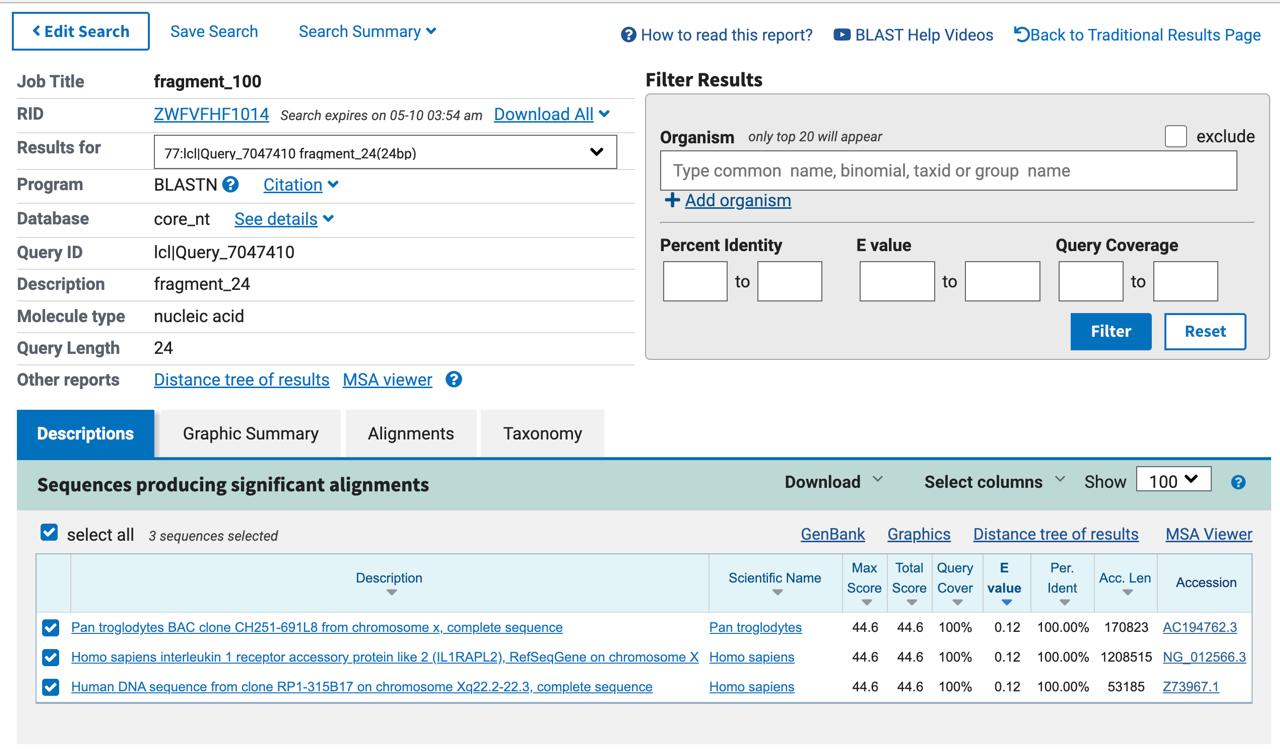

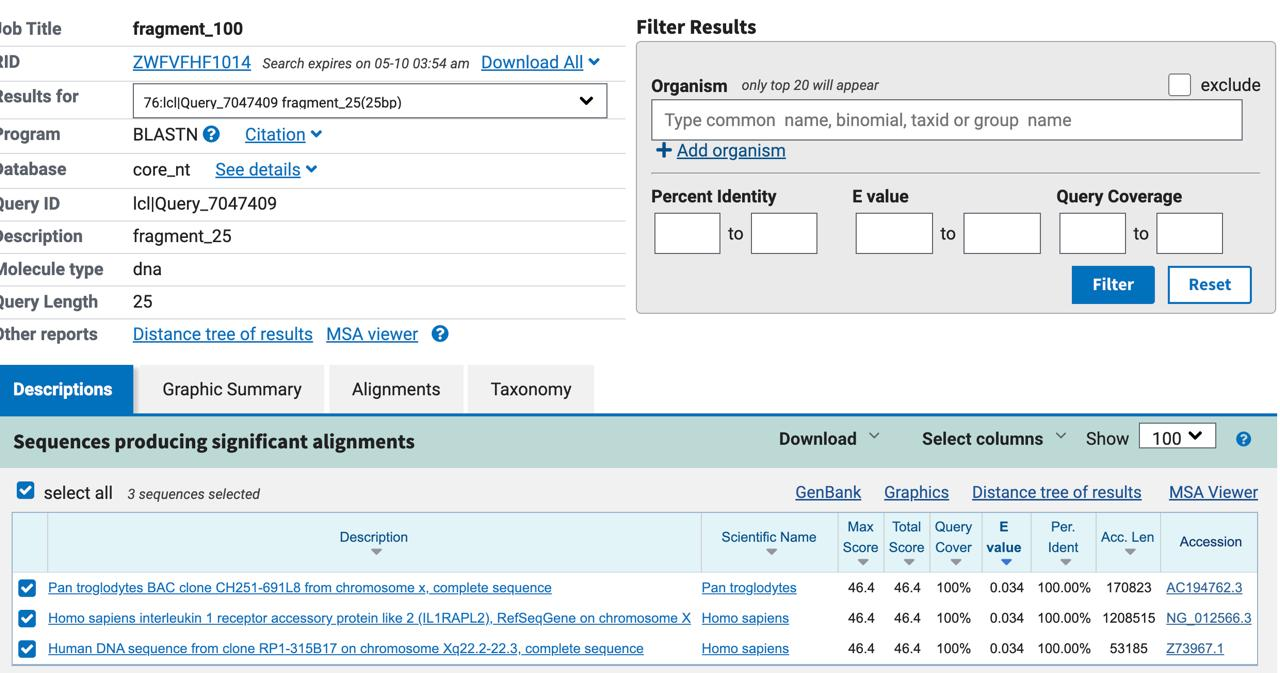

это с человеком

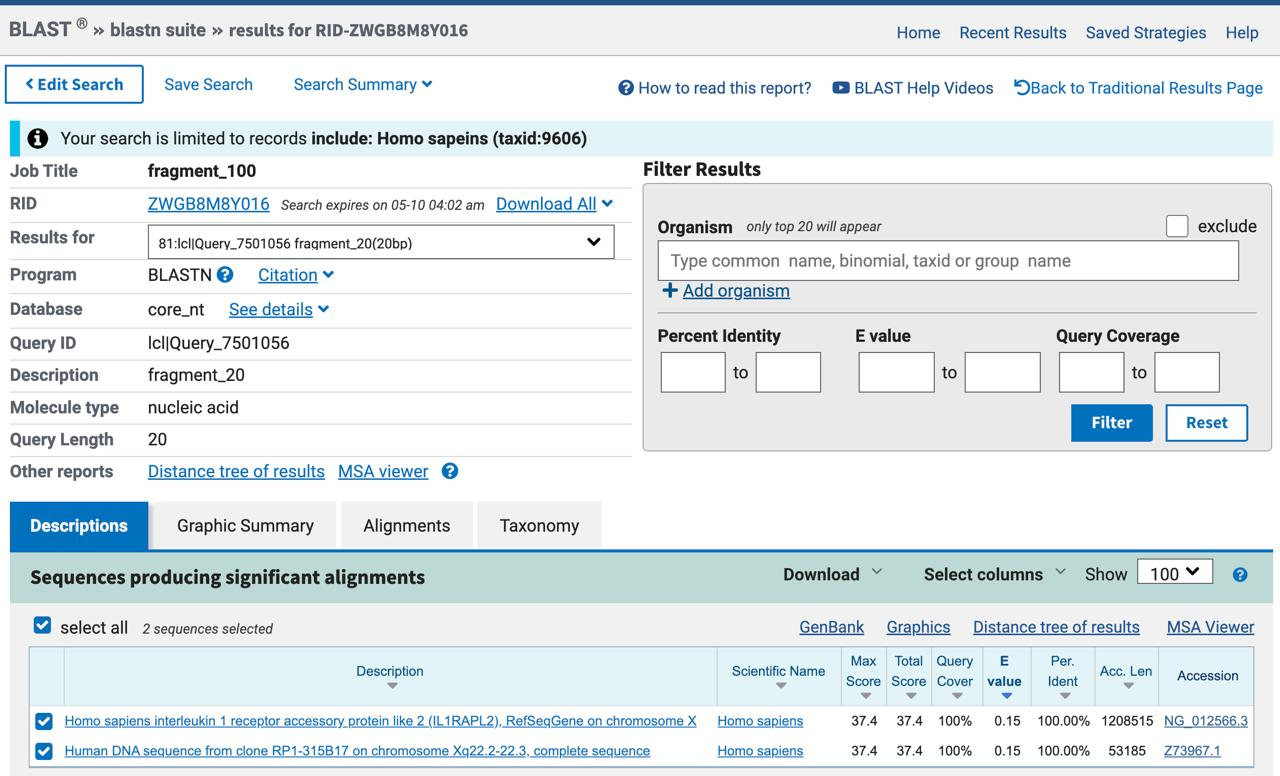

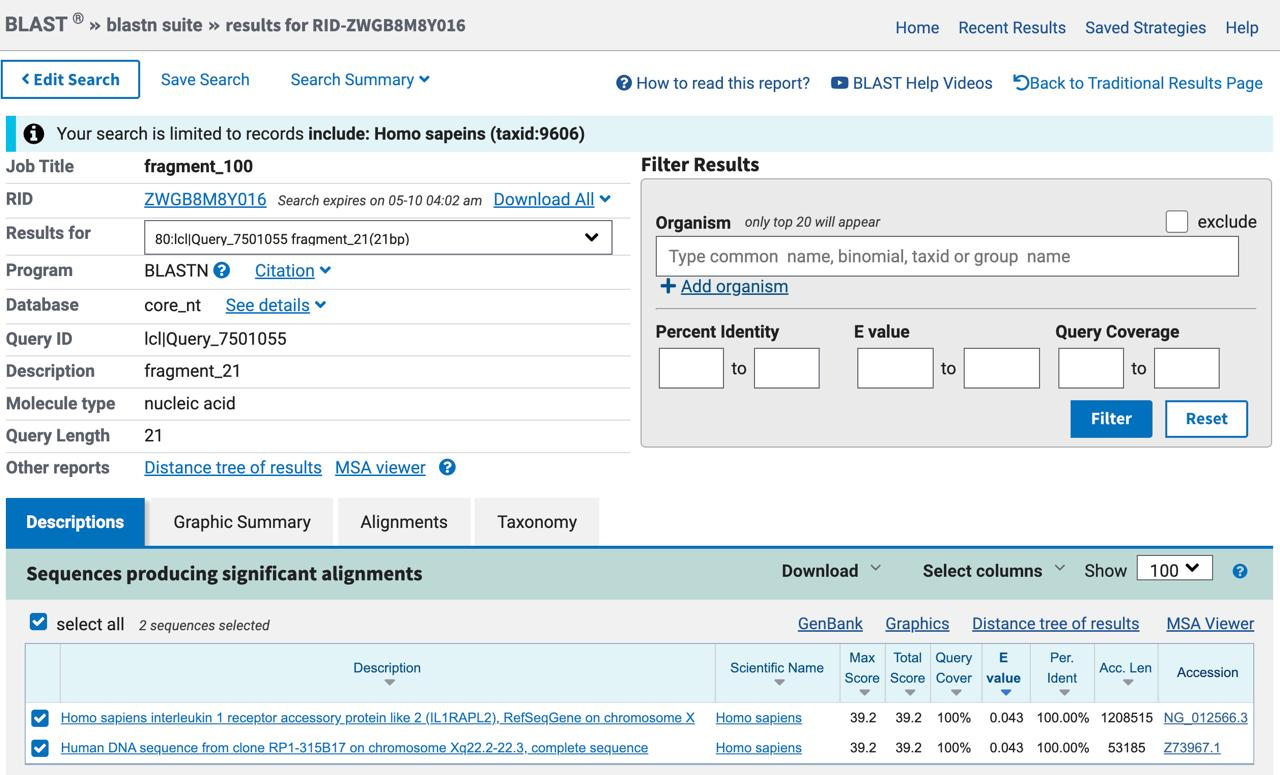

В сухом остатке: если ограничивать поиск только человеком, e-value дольше остается значимым (без человека на длине 24 bp, с человеком на длине 20 bp).

Опираясь на определение e-value (как я понимаю, если очень упрощать – это как бы вероятность того, что качество случайного выравнивания будет выше, чем качество выравнивания на взятый геном), можно предположить, что из-за менее обширного объема базы данных (при использовании только человеческого генома для поиска совпадений) шанс найти случайное совпадение меньше – поэтому e-value дольше остается в разумных пределах.

####Задание на 9-10 (графики)

Здесь я взяла для построения графиков результат без фиксирования человека (это не было уточнено в задании).

In [146]:
df_nohuman = pd.read_csv('/content/ZY8T1808016-Alignment-HitTable.csv',
                         usecols=[0, 2, 10],
                         names=['length', 'identity', 'e-value'])

In [147]:
df_nohuman

,length,identity,e-value
0,fragment_100,100.0,1.390000e-41
1,fragment_100,100.0,1.390000e-41
2,fragment_100,100.0,1.390000e-41
3,fragment_100,82.0,3.720000e-17
4,fragment_100,82.0,3.720000e-17
...,...,...,...
9122,fragment_24,100.0,1.200000e-01
9123,fragment_24,100.0,1.200000e-01
9124,fragment_23,100.0,4.200000e-01
9125,fragment_23,100.0,4.200000e-01


In [148]:
df_best_evalue = df_nohuman.groupby('length').first().reset_index()
df_best_evalue = pd.concat([df_best_evalue.iloc[1:], df_best_evalue.iloc[:1]])
df_best_evalue['length'] = df_best_evalue['length'].str.replace('fragment_',
                                                                '').astype(int)

In [149]:
df_best_evalue

,length,identity,e-value
1,23,100.0,4.200000e-01
2,24,100.0,1.200000e-01
3,25,100.0,3.400000e-02
4,26,100.0,1.000000e-02
5,27,100.0,3.000000e-03
...,...,...,...
74,96,100.0,1.930000e-39
75,97,100.0,5.610000e-40
76,98,100.0,1.630000e-40
77,99,100.0,4.760000e-41


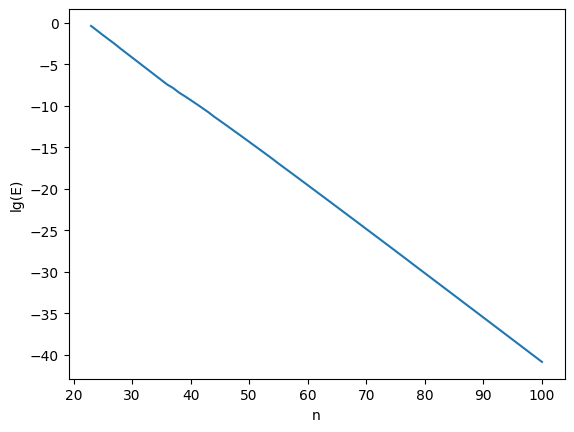

In [150]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(df_best_evalue['length'], np.log10(df_best_evalue['e-value']))
plt.xlabel('n'); plt.ylabel('lg(E)')
plt.show()

очень миленько хихи

In [151]:
df_best_identity = df_nohuman[df_nohuman['identity']
                                    == df_nohuman.
                                    groupby('length')['identity'].
                                    transform('max')]

df_best_identity['length'] = df_best_identity['length'].str.replace('fragment_',
                                                                '').astype(int)

df_best_identity

/tmp/ipykernel_7410/2751715605.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_best_identity['length'] = df_best_identity['length'].str.replace('fragment_',


,length,identity,e-value
0,100,100.0,1.390000e-41
1,100,100.0,1.390000e-41
2,100,100.0,1.390000e-41
215,99,100.0,4.760000e-41
216,99,100.0,4.760000e-41
...,...,...,...
9122,24,100.0,1.200000e-01
9123,24,100.0,1.200000e-01
9124,23,100.0,4.200000e-01
9125,23,100.0,4.200000e-01


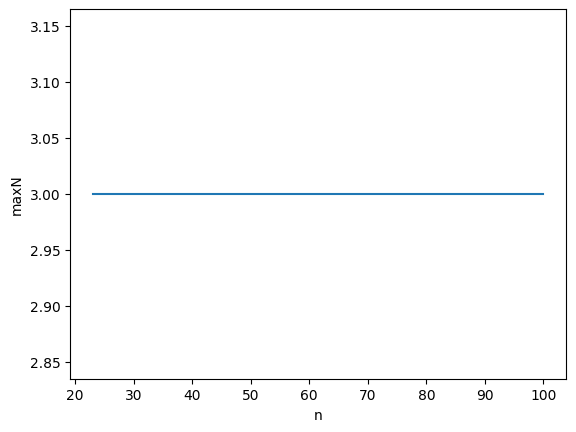

In [152]:
identity_dict = df_best_identity.groupby('length')['identity'].apply(lambda x: (x == x.max()).sum()).to_dict()

plt.plot(identity_dict.keys(), identity_dict.values())
plt.xlabel('n'); plt.ylabel('maxN')
plt.show()

не очень миленько – тут я не поняла, с чем это связано(